# Path Signatures for Time Series Feature Engineering

**Docker image**: `ml4t-py312`

> **Docker required**: This notebook uses `esig`, which is an x86-only package
> not included in the default environment. Run with:
> ```bash
> docker compose --profile py312 run --rm py312 python 09_model_based_features/06_path_signatures.py
> ```

Path signatures provide a mathematical framework for capturing sequential information
in time series. Unlike lagged features that compress history into fixed windows, signatures
encode the complete path dynamics — direction changes, reversals, and higher-order patterns.

**Learning Objectives**:
- Understand path signatures as feature extraction for ordered data
- Compute signatures using the esig library with time augmentation
- Apply depth truncation and log-signatures for dimensionality control
- Compare signature features against traditional lag features for predictability

**Book Reference**: Chapter 9, Section 9.2 (Signal Transforms and Spectral Features)

**Prerequisites**: `04_kalman_filter` and `05_spectral_features` for other
signal transform approaches.

In [1]:
"""Path Signatures for Time Series Feature Engineering — extract sequential features using signature transforms."""

import importlib
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import pooled_ic
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
# Production defaults — Papermill injects overrides for CI
WINDOW_SIZE = 20
FORECAST_HORIZON = 5
SIGNATURE_DEPTH = 3
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
# `esig` ships only in the py312 image (x86 only); fail loud if we're
# running outside it.
try:
    esig = importlib.import_module("esig")
except ImportError as exc:
    raise ImportError(
        "`esig` is not available in the current image.\n"
        "This notebook runs in the `ml4t-py312` image:\n"
        "  docker compose --profile py312 run --rm py312 \\\n"
        "      python 09_model_based_features/06_path_signatures.py"
    ) from exc

## What Are Path Signatures?

A **path signature** is a mathematical object that summarizes a continuous path's shape.
For a $d$-dimensional path $X: [0,T] \rightarrow \mathbb{R}^d$, the signature collects
all iterated integrals up to a given depth:

$$S(X)^{i_1, \ldots, i_k} = \int_{0 < t_1 < \cdots < t_k < T} dX_{t_1}^{i_1} \cdots dX_{t_k}^{i_k}$$

At **depth 1**, the signature records the total displacement along each coordinate —
equivalent to net return. At **depth 2**, cross-terms appear: $S^{1,2}$ captures the
"area" swept between dimensions 1 and 2, encoding whether dimension 1 moved before or
after dimension 2 (lead-lag structure). Higher depths capture progressively finer
path geometry.

**Key properties for feature engineering**:
- **Reparameterization invariance**: Signatures capture *what* happened, not *when* — the
  same price trajectory traversed quickly or slowly yields identical features.
- **Universality**: Different paths produce different signatures (the signature separates paths).
- **Truncation**: The full signature is infinite-dimensional. In practice, truncation at depth
  $K$ (typically 2–4) retains the most informative terms.

For finance: a price path rising from 100 to 110 then falling to 105 has a different
signature than one that falls then rises, even if both end at 105.

### Truncation Depth and Feature Interpretation

Each truncation depth adds a new "layer" of path structure:

| Depth | Terms | Interpretation | Example (price + volume path) |
|-------|-------|---------------|-------------------------------|
| 1 | $d$ | Total displacement (net changes) | Net return, net volume change |
| 2 | $d + d^2$ | Pairwise interactions (lead-lag, area) | Did volume lead or lag the price move? |
| 3 | $d + d^2 + d^3$ | Third-order interactions | Acceleration patterns, reversal sequences |

**Log-signatures** provide a more compact alternative. The log-signature lives in the
free Lie algebra and removes algebraic redundancies present in the full signature.
For a $d$-dimensional path at depth $K$, the log-signature has dimension
$\sum_{k=1}^{K} \frac{1}{k} \sum_{j|k} \mu(k/j) \, d^j$ (Möbius function),
which is substantially smaller than the full signature's $\sum_{k=1}^{K} d^k$ terms.
In practice, log-signatures are preferred for regression tasks: more compact, less
redundant, and equally expressive.

### Time Augmentation

For financial data, **time-augmented paths** are essential. Without time as an explicit
coordinate, a path that rises from 100 to 110 and one that falls from 100 to 90 differ
only in sign — but a path rising then falling (ending at 100) and one falling then rising
(also ending at 100) produce *identical* depth-1 signatures. Adding a monotonically
increasing time coordinate $t \in [0, 1]$ breaks this ambiguity: the depth-2 cross-term
between time and price captures whether the path rose early or late.

The augmented path takes the form $(t, \text{price}_t, \text{volume}_t, \ldots)$. For a
5-day window on an ETF with price rising then falling, the depth-1 signature captures
net return $\approx 0$; the depth-2 cross-term between time and price captures whether
the peak occurred early or late in the window — information invisible to standard lag
features. The depth-2 cross-term between price and volume captures whether volume led or
lagged the reversal.

## Load Data

In [5]:
# Load ETF universe (filtered to major index ETFs for demonstration)
symbols = ["SPY", "QQQ", "IWM", "EFA"]
df = load_etfs(symbols=symbols)
df = df.sort(["symbol", "timestamp"])

# Check date range
print(f"Assets: {df['symbol'].unique().to_list()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total rows: {len(df):,}")

Assets: ['EFA', 'SPY', 'IWM', 'QQQ']
Date range: 2006-01-03 to 2025-12-31
Total rows: 20,124


## Prepare Price Paths

For signatures, we need to convert discrete price series into paths.
We'll use overlapping windows to create many training examples.

In [6]:
# WINDOW_SIZE, FORECAST_HORIZON, SIGNATURE_DEPTH set in parameters cell


def create_paths_and_targets(
    symbol_df: pl.DataFrame, window_size: int = 20, horizon: int = 5
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Create overlapping windows for signature computation.

    Returns:
        paths: Array of shape (n_windows, window_size, n_features)
        targets: Forward returns
        dates: End dates for each window
    """
    # Compute returns and normalize prices
    symbol_df = symbol_df.sort("timestamp")
    symbol_df = symbol_df.with_columns(
        ret=pl.col("close").pct_change(),
        log_ret=pl.col("close").log().diff(),
        norm_vol=(pl.col("volume") - pl.col("volume").mean()) / pl.col("volume").std(),
    ).drop_nulls()

    # Compute forward returns for targets
    symbol_df = symbol_df.with_columns(
        fwd_ret=pl.col("close").pct_change(horizon).shift(-horizon),
    )

    # Convert to numpy for windowing
    timestamps = symbol_df["timestamp"].to_numpy()
    closes = symbol_df["close"].to_numpy()
    returns = symbol_df["ret"].to_numpy()
    fwd_returns = symbol_df["fwd_ret"].to_numpy()

    # Create overlapping windows
    n = len(symbol_df)
    n_windows = n - window_size - horizon + 1

    if n_windows <= 0:
        return np.array([]), np.array([]), np.array([])

    # Each path has (time, price, return) - 3D path for richer signatures
    paths = []
    targets = []
    dates = []

    for i in range(n_windows):
        # Normalize time to [0, 1]
        t = np.linspace(0, 1, window_size).reshape(-1, 1)

        # Normalize price within window (start at 0)
        window_closes = closes[i : i + window_size]
        norm_price = (window_closes - window_closes[0]) / window_closes[0]
        norm_price = norm_price.reshape(-1, 1)

        # Cumulative returns
        window_rets = returns[i : i + window_size]
        cum_ret = np.cumsum(window_rets).reshape(-1, 1)

        # Combine into path: (time, price, cumulative return)
        path = np.hstack([t, norm_price, cum_ret])
        paths.append(path)

        # Target: forward return at window end
        target_idx = i + window_size - 1
        targets.append(fwd_returns[target_idx])
        dates.append(timestamps[target_idx])

    paths = np.array(paths)
    targets = np.array(targets)
    dates = np.array(dates)

    # Remove NaN targets
    valid_mask = ~np.isnan(targets)
    return paths[valid_mask], targets[valid_mask], dates[valid_mask]


# Create paths for SPY
spy = df.filter(pl.col("symbol") == "SPY")
paths, targets, dates = create_paths_and_targets(spy, WINDOW_SIZE, FORECAST_HORIZON)
print(f"Created {len(paths)} paths of shape {paths.shape[1:]}")
print(f"Target stats: mean={targets.mean():.4f}, std={targets.std():.4f}")

Created 5006 paths of shape (20, 3)
Target stats: mean=0.0024, std=0.0245


## Compute Path Signatures

The `esig` library computes signatures efficiently. We use:
- **Depth 3**: Captures up to third-order interactions between path components
- **Log signature**: A more compact representation that avoids redundancy

In [7]:
def compute_signatures(paths: np.ndarray, depth: int = 3) -> np.ndarray:
    """Compute path signatures for a batch of paths."""
    n_paths = len(paths)
    signatures = []

    for i in range(n_paths):
        path = paths[i]
        # esig expects paths as 2D arrays (n_points, n_dims)
        sig = esig.stream2sig(path, depth)
        signatures.append(sig)

    return np.array(signatures)

In [8]:
def compute_logsignatures(paths: np.ndarray, depth: int = 3) -> np.ndarray:
    """Compute log signatures (more compact) for a batch of paths."""
    n_paths = len(paths)
    logsigs = []

    for i in range(n_paths):
        path = paths[i]
        logsig = esig.stream2logsig(path, depth)
        logsigs.append(logsig)

    return np.array(logsigs)


# Compute both signature types
signatures = compute_signatures(paths, SIGNATURE_DEPTH)
logsignatures = compute_logsignatures(paths, SIGNATURE_DEPTH)

print(f"Signature dimension (depth {SIGNATURE_DEPTH}): {signatures.shape[1]}")
print(f"Log-signature dimension (depth {SIGNATURE_DEPTH}): {logsignatures.shape[1]}")

Signature dimension (depth 3): 40
Log-signature dimension (depth 3): 14


### Computational Complexity

The signature dimension grows exponentially with depth: for a $d$-dimensional path
truncated at depth $K$, `esig` returns $1 + \sum_{k=1}^{K} d^k$ terms (the leading
term is the constant level-0 scalar $1$). Our 3-dimensional path (time, price,
cumulative return) at depth 3 produces $1 + 3 + 9 + 27 = 40$ features. A
5-dimensional path (e.g., multi-asset) at depth 3 would produce
$1 + 5 + 25 + 125 = 156$ features per window.

Log-signatures are substantially more compact: the same 3D path at depth 3 yields
only 14 log-signature terms (vs. 40 full signature terms). This compactness makes
log-signatures the pragmatic default for production use.

**Practical guideline**: Truncation at depth 2 is sufficient for most daily-frequency
applications. Depth 3 adds marginal value for intraday data where third-order
interactions (acceleration patterns) carry signal. Depth 4+ rarely justifies the
exponential feature growth and overfitting risk.

## Baseline: Traditional Lag Features

For comparison, we create standard technical features from the same windows.

In [9]:
def create_lag_features(paths: np.ndarray) -> np.ndarray:
    """
    Create traditional lag-based features from price windows.

    Features:
    - Window return
    - Volatility (std of returns)
    - First-half vs second-half momentum
    - Min/max relative to end
    - Skewness proxy
    """
    n_paths = len(paths)
    features = []

    for i in range(n_paths):
        path = paths[i]
        price = path[:, 1]  # Normalized price column
        cum_ret = path[:, 2]  # Cumulative return column

        # Total window return
        total_ret = price[-1] - price[0]

        # Volatility (std of increments)
        increments = np.diff(price)
        vol = np.std(increments)

        # Momentum: second half vs first half
        mid = len(price) // 2
        first_half_ret = price[mid] - price[0]
        second_half_ret = price[-1] - price[mid]
        momentum = second_half_ret - first_half_ret

        # Drawdown and runup
        max_price = np.max(price)
        min_price = np.min(price)
        max_relative = max_price - price[-1]
        min_relative = price[-1] - min_price

        # Skewness proxy (mean - median)
        skew_proxy = np.mean(price) - np.median(price)

        # Path roughness (sum of absolute increments)
        roughness = np.sum(np.abs(increments))

        feat = [
            total_ret,
            vol,
            momentum,
            max_relative,
            min_relative,
            skew_proxy,
            roughness,
        ]
        features.append(feat)

    return np.array(features)


lag_features = create_lag_features(paths)
print(f"Lag features dimension: {lag_features.shape[1]}")

Lag features dimension: 7


## Predictive Comparison: Signatures vs Lags

We compare three feature sets for predicting 5-day forward returns using
a simple GBM as a test harness. This is **feature evaluation, not model
building** — we use a single learner to measure relative feature
informativeness. Model selection and tuning are covered in Chapter 12.

Feature sets:
1. Traditional lag features
2. Path signatures
3. Combined (signatures + lags)

In [10]:
# Split data temporally (avoid look-ahead)
train_size = int(0.7 * len(paths))
val_size = int(0.15 * len(paths))

X_lag_train = lag_features[:train_size]
X_lag_val = lag_features[train_size : train_size + val_size]
X_lag_test = lag_features[train_size + val_size :]

X_sig_train = logsignatures[:train_size]
X_sig_val = logsignatures[train_size : train_size + val_size]
X_sig_test = logsignatures[train_size + val_size :]

y_train = targets[:train_size]
y_val = targets[train_size : train_size + val_size]
y_test = targets[train_size + val_size :]

# Combined features
X_comb_train = np.hstack([X_lag_train, X_sig_train])
X_comb_val = np.hstack([X_lag_val, X_sig_val])
X_comb_test = np.hstack([X_lag_test, X_sig_test])

print(f"Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

Train: 3504, Val: 750, Test: 752


In [11]:
# Train models
models = {}


def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, name):
    """Train GradientBoosting and return metrics."""
    model = GradientBoostingRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
    )
    model.fit(X_train, y_train)

    train_r2 = r2_score(y_train, model.predict(X_train))
    val_r2 = r2_score(y_val, model.predict(X_val))
    test_r2 = r2_score(y_test, model.predict(X_test))

    # Information coefficient (rank correlation)
    test_pred = model.predict(X_test)
    ic = pooled_ic(y_test, test_pred)

    return {"train_r2": train_r2, "val_r2": val_r2, "test_r2": test_r2, "ic": ic, "model": model}


results = {
    "Lag Features": train_and_evaluate(
        X_lag_train, X_lag_val, X_lag_test, y_train, y_val, y_test, "Lag"
    ),
    "Log-Signatures": train_and_evaluate(
        X_sig_train, X_sig_val, X_sig_test, y_train, y_val, y_test, "Sig"
    ),
    "Combined": train_and_evaluate(
        X_comb_train, X_comb_val, X_comb_test, y_train, y_val, y_test, "Combined"
    ),
}

## Results Comparison

In [12]:
# Predictive performance across feature sets (5-day forward returns)
results_df = pl.DataFrame(
    {
        "Feature Set": list(results.keys()),
        "Train R²": [res["train_r2"] for res in results.values()],
        "Val R²": [res["val_r2"] for res in results.values()],
        "Test R²": [res["test_r2"] for res in results.values()],
        "Test IC": [res["ic"] for res in results.values()],
    }
).with_columns(pl.col(pl.Float64).round(4))
results_df

Feature Set,Train R²,Val R²,Test R²,Test IC
str,f64,f64,f64,f64
"""Lag Features""",0.3769,-0.0797,-0.01,0.0925
"""Log-Signatures""",0.3442,-0.0582,-0.0163,0.0906
"""Combined""",0.4022,-0.1567,0.0148,0.136


**Interpretation**:

Out-of-sample $R^2$ is near zero for every feature set (lag features: $-0.010$,
log-signatures: $-0.016$, combined: $+0.015$), which is typical for daily
return prediction. Rank correlation is more informative on this single-split
evaluation: combined features achieve a test IC of $0.136$, versus $0.093$
for lag features alone and $0.091$ for log-signatures alone. Signatures and
lag features are therefore complementary on this dataset; the notebook does
not evaluate turnover, capacity, or transaction costs, so it does not
establish tradeability of the IC gap.

## Visualize Signature Feature Importance

Importance is the gradient-boosting impurity reduction (`feature_importances_`),
which measures predictive contribution to this single model, not causal importance.

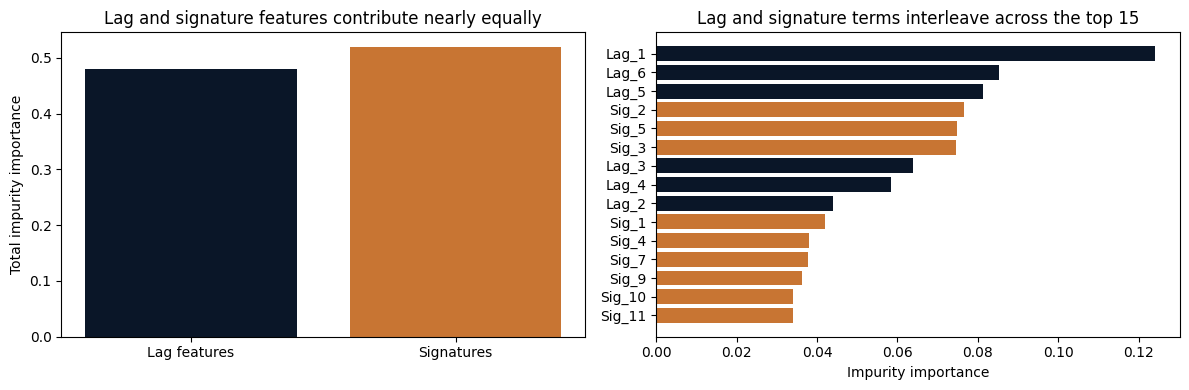

In [13]:
# Feature importance for combined model (impurity-based)
combined_model = results["Combined"]["model"]
n_lag = lag_features.shape[1]
n_sig = logsignatures.shape[1]

importances = combined_model.feature_importances_
lag_imp = importances[:n_lag].sum()
sig_imp = importances[n_lag:].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Importance by category
ax = axes[0]
ax.bar(["Lag features", "Signatures"], [lag_imp, sig_imp], color=[COLORS["blue"], COLORS["copper"]])
ax.set_ylabel("Total impurity importance")
ax.set_title("Lag and signature features contribute nearly equally")

# Top individual features
ax = axes[1]
feature_names = [f"Lag_{i}" for i in range(n_lag)] + [f"Sig_{i}" for i in range(n_sig)]
top_k = 15
top_idx = np.argsort(importances)[-top_k:][::-1]
ax.barh(
    [feature_names[i] for i in top_idx],
    importances[top_idx],
    color=[COLORS["blue"] if i < n_lag else COLORS["copper"] for i in top_idx],
)
ax.set_xlabel("Impurity importance")
ax.set_title(f"Lag and signature terms interleave across the top {top_k}")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Multi-Asset Signature Analysis

Signatures can capture cross-asset dynamics by computing signatures on multi-asset paths.

In [14]:
def create_multi_asset_paths(
    df: pl.DataFrame, symbols: list[str], window_size: int = 20
) -> tuple[np.ndarray, list]:
    """
    Create paths where each path has multiple asset returns as dimensions.
    """
    # Pivot to wide format
    wide = df.pivot(on="symbol", index="timestamp", values="close").sort("timestamp").drop_nulls()

    # Compute returns
    for sym in symbols:
        wide = wide.with_columns(
            ((pl.col(sym) - pl.col(sym).shift(1)) / pl.col(sym).shift(1)).alias(f"{sym}_ret")
        )

    wide = wide.drop_nulls()

    # Create windows
    n = len(wide)
    n_windows = n - window_size

    if n_windows <= 0:
        return np.array([]), []

    paths = []
    end_dates = []

    ret_cols = [f"{sym}_ret" for sym in symbols]

    for i in range(n_windows):
        window = wide[i : i + window_size]

        # Time augmentation
        t = np.linspace(0, 1, window_size).reshape(-1, 1)

        # Cumulative returns for each asset
        asset_paths = []
        for col in ret_cols:
            cum_ret = window[col].cum_sum().to_numpy().reshape(-1, 1)
            asset_paths.append(cum_ret)

        # Combine: (time, asset1_cumret, asset2_cumret, ...)
        path = np.hstack([t] + asset_paths)
        paths.append(path)
        end_dates.append(window["timestamp"][-1])

    return np.array(paths), end_dates


# Create multi-asset paths
multi_paths, multi_dates = create_multi_asset_paths(df, symbols, WINDOW_SIZE)
if len(multi_paths) > 0:
    print(f"Multi-asset paths: {len(multi_paths)} windows, dimension {multi_paths.shape[2]}")

    # Compute signatures
    multi_sigs = compute_logsignatures(multi_paths, depth=2)  # Lower depth due to higher dim
    print(f"Multi-asset log-signature dimension: {multi_sigs.shape[1]}")
else:
    print("Insufficient data for multi-asset paths")

Multi-asset paths: 5010 windows, dimension 5
Multi-asset log-signature dimension: 15


## When to Use Signatures

**Signatures improve over baseline lag features when path shape genuinely matters**:
intraday microstructure (execution timing, order flow patterns), options expiration
dynamics (gamma hedging creates distinctive intraday paths), and momentum decay
patterns (distinguishing gradual trends from sharp reversals).

**For daily equity data with trend-following objectives, the marginal gain over
well-constructed lag features is often modest.** Test signatures when simpler features
plateau and when execution timing depends on path characteristics.

**Signatures excel when**:
- Path shape matters more than specific values (pattern recognition)
- You need features invariant to speed of execution (reparameterization invariance)
- Higher-order interactions between path components are informative
- You're building features for ML models (tree-based, neural networks)

**Signatures may not help when**:
- The signal is purely in levels/returns (simple momentum)
- Computational budget is very tight (cost is $O(n \times d^K)$ per window)
- Interpretability is paramount (individual signature terms are abstract)

**Multi-asset signatures** capture lead-lag dynamics across instruments — for example,
whether tech momentum (QQQ) consistently leads broad-market moves (SPY). This
cross-asset application connects to the panel features in §9.6.

**Rolling computation** over trailing windows maintains causality: at time $t$, compute
the signature over $[t - W, t]$ only. Typical windows range from 5 to 60 days.

**Practical tip**: Start with depth-2 log-signatures. Higher depths rarely help and
increase overfitting risk. For multi-asset paths, reduce depth to 2 to keep feature
counts manageable.

## Summary

In [15]:
summary = {
    "Data": "SPY ETF daily prices",
    "Window size": f"{WINDOW_SIZE} days",
    "Forecast horizon": f"{FORECAST_HORIZON} days",
    "Signature depth": SIGNATURE_DEPTH,
    "Signature dimension": signatures.shape[1],
    "Log-signature dimension": logsignatures.shape[1],
    "Lag features dimension": lag_features.shape[1],
    "Best IC (Test)": f"{max(r['ic'] for r in results.values()):.4f}",
    "Best model": max(results.keys(), key=lambda k: results[k]["ic"]),
}

print("\n=== Summary ===")
for key, value in summary.items():
    print(f"{key}: {value}")


=== Summary ===
Data: SPY ETF daily prices
Window size: 20 days
Forecast horizon: 5 days
Signature depth: 3
Signature dimension: 40
Log-signature dimension: 14
Lag features dimension: 7
Best IC (Test): 0.1360
Best model: Combined


## Key Takeaways

1. **Path signatures encode sequential structure** that traditional features miss
2. **Time augmentation is critical** - without it, rising and falling paths look identical
3. **Log-signatures are preferred** in practice (more compact, less redundant)
4. **Depth 2-3 is usually sufficient** - higher depths risk overfitting
5. **Signatures complement, don't replace** traditional features
6. **Cross-asset signatures** can capture lead-lag and correlation dynamics

**Previous**: `04_kalman_filter` for Kalman-based features,
`05_spectral_features` for frequency-domain features.
**Next**: `07_arima_features` for time-domain forecasting features.
Ch12 uses these enriched features in gradient boosting models.